# Machine Learning Foundations

From the core idea (programs that learn from data) to a working classifier built from scratch.

### The problem with writing rules by hand

Suppose you want a program that decides whether a photo contains a cat. You could try to write rules: look for pointy ears, whiskers, a certain fur texture. But the rules multiply endlessly. A cat from behind has no visible whiskers. A cartoon cat has no texture at all. An orange on a pile of pillows has roughly the right color and shape. Any rule you write, reality has a counterexample.

This is the wall that traditional programming hits: **for complex tasks, we cannot write down the rules**. We recognize cats instantly but cannot articulate how.

**Machine learning** takes a different approach. Instead of writing rules, we provide examples (thousands of photos labeled "cat" or "not cat") and let the program discover the rules itself. The rules are never written down explicitly. They are encoded in the numbers the program learns.

This is the fundamental shift ML makes:

| Traditional programming | Machine learning |
|------------------------|------------------|
| You write rules + data → program produces answers | You provide data + answers → program discovers rules |
| Rules are explicit, readable | Rules are implicit, encoded in numbers |
| Fails when rules are too complex to write | Succeeds when you have enough examples |

### What this notebook covers

We build everything from scratch: no ML libraries, just Python and `math`. By the end, you will have:

- A precise vocabulary for the supervised learning setup
- A working linear regression model trained by hand
- A clear understanding of gradient descent, what it is and why it works
- The four-step training loop that runs through every notebook in this series
- A working logistic regression classifier
- An understanding of why a held-out validation set is not optional

Every subsequent notebook is this notebook with a bigger model in the middle.

| Step | What we build | Why we need it |
|------|--------------|----------------|
| 1 | The supervised learning setup | The vocabulary and structure every ML system shares |
| 2 | Linear regression | The simplest model: one line through data |
| 3 | The loss function | How to turn "how wrong are we?" into one number |
| 4 | Gradient descent | How to adjust parameters to lower the loss |
| 5 | The training loop | The four steps that train any ML model |
| 6 | Generalization | Why we need held-out data and what overfitting looks like |
| 7 | Classification | From regression to decisions: logistic regression |

In [1]:
import math
import random
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1: The Supervised Learning Setup

Every supervised learning problem has the same four ingredients.

**Features** (`x`): the inputs we feed to the model. For house price prediction, this might be square footage, number of bedrooms, distance to the city centre. For character prediction, it's the preceding characters. We often write a single example's features as a vector `x = [x₁, x₂, ..., xₙ]`.

**Target** (`y`): the answer we want the model to produce. For house prices, this is the sale price in dollars. For character prediction, it's the next character. The target is also called the **label** or **ground truth**.

**Model** (`f`): a function that maps features to a prediction. `ŷ = f(x)`. The hat on `ŷ` (pronounced "y-hat") signals that this is the model's *estimate*, not the true `y`. The model has **parameters**, numbers that control its behaviour, and these are what we adjust during training.

**Loss** (`L`): a single number measuring how wrong the current prediction is. `L = loss(ŷ, y)`. Small loss = good. Zero loss = perfect. The loss tells the model which way is "wrong" so it knows which way to improve.

**Training** is the process of repeatedly adjusting the model's parameters to lower the loss. We repeat it for many examples until the model's predictions are useful.

### A concrete task

We need something simple enough to understand completely. We will use a toy **house price** dataset:

- Feature `x`: house size in hundreds of square feet (so `x = 15` means 1500 sq ft)
- Target `y`: price in tens of thousands of dollars

We generate a synthetic dataset: the "true" relationship is `price = 3 × size + 5`, with some added noise (because real data is never perfectly clean).

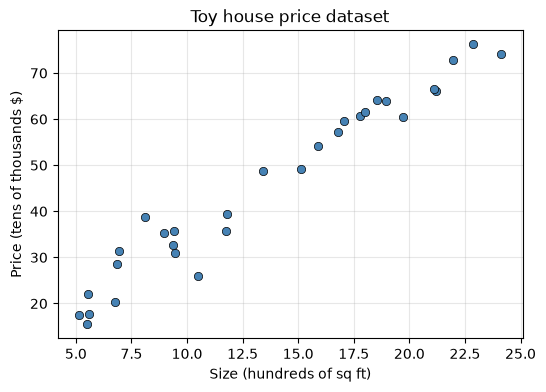

Dataset: 30 houses
Size range: 5.1 – 24.1  |  Price range: 15.4 – 76.2


In [2]:
random.seed(42)

# True relationship: price = 3 * size + 5 (+ noise)
TRUE_W = 3.0
TRUE_B = 5.0

n = 30
X = [random.uniform(5, 25) for _ in range(n)]          # house sizes: 500–2500 sq ft
y = [TRUE_W * xi + TRUE_B + random.gauss(0, 4) for xi in X]  # prices with noise

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='steelblue', edgecolors='k', linewidth=0.5, zorder=3)
plt.xlabel('Size (hundreds of sq ft)')
plt.ylabel('Price (tens of thousands $)')
plt.title('Toy house price dataset')
plt.grid(alpha=0.3)
plt.show()

print(f'Dataset: {n} houses')
print(f'Size range: {min(X):.1f} – {max(X):.1f}  |  Price range: {min(y):.1f} – {max(y):.1f}')

## Step 2: Linear Regression

The simplest model is a straight line:

```
ŷ = w * x + b
```

`w` is the **weight** (slope): how much the prediction changes per unit of input. `b` is the **bias** (intercept): the prediction when the input is zero. Together, `w` and `b` are the model's two **parameters**.

We want to find the values of `w` and `b` that make the line fit the data as well as possible. Right now we have no idea what those values are, so we start with guesses.

Why is this called *linear* regression? "Linear" because the prediction is a linear function of the input: changing `x` by one unit always changes `ŷ` by exactly `w`, regardless of where you are on the line. "Regression" is the statistical term for predicting a continuous number (as opposed to a category).

### The model is just a function

The model is defined entirely by its parameters. Given fixed `w` and `b`, it maps any input `x` to a prediction. Two different sets of parameters describe two different lines, which means two different functions.

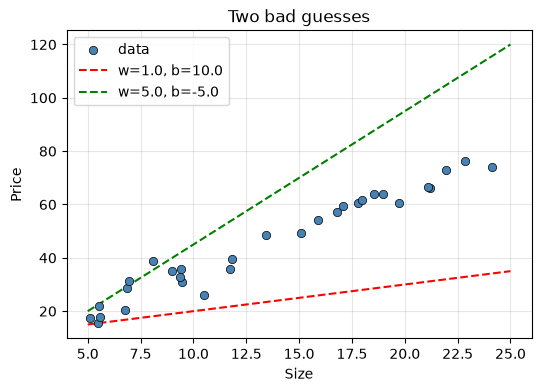

In [3]:
def predict(x, w, b):
    return w * x + b

# Two guesses: what do they look like compared to the data?
w_guess1, b_guess1 = 1.0, 10.0   # too shallow
w_guess2, b_guess2 = 5.0, -5.0   # too steep, wrong intercept

x_line = [5, 25]

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='steelblue', edgecolors='k', linewidth=0.5, zorder=3, label='data')
plt.plot(x_line, [predict(xi, w_guess1, b_guess1) for xi in x_line], 'r--', label=f'w={w_guess1}, b={b_guess1}')
plt.plot(x_line, [predict(xi, w_guess2, b_guess2) for xi in x_line], 'g--', label=f'w={w_guess2}, b={b_guess2}')
plt.xlabel('Size'); plt.ylabel('Price')
plt.title('Two bad guesses')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Step 3: The Loss Function

Both guesses look wrong, but "wrong" is vague. We need one number that quantifies how wrong, so we can compare guesses and know which direction to adjust.

For regression, the standard choice is **Mean Squared Error (MSE)**:

```
MSE = (1/n) * Σ (ŷᵢ - yᵢ)²
```

For each example: compute the error `(ŷᵢ - yᵢ)` (prediction minus true value), square it, then average across all examples.

Why square the errors?
- **Sign cancellation**: a prediction 5 too high and one 5 too low average to zero error, but they're both wrong. Squaring makes both positive so they can't cancel.
- **Penalise big errors more**: doubling an error quadruples its penalty. An error of 5 costs 25; an error of 10 costs 100. Large mistakes are punished disproportionately.

The MSE is zero if and only if every prediction is exactly right. Otherwise it's positive. Our job is to find parameters `w` and `b` that minimise it.

In [4]:
def mse_loss(X, y, w, b):
    n = len(X)
    total = sum((predict(xi, w, b) - yi) ** 2 for xi, yi in zip(X, y))
    return total / n

loss1 = mse_loss(X, y, w_guess1, b_guess1)
loss2 = mse_loss(X, y, w_guess2, b_guess2)
print(f'Guess 1 (w={w_guess1}, b={b_guess1}):  MSE = {loss1:.2f}')
print(f'Guess 2 (w={w_guess2}, b={b_guess2}): MSE = {loss2:.2f}')

# Sanity check: the true parameters should produce a lower loss than both guesses
loss_true = mse_loss(X, y, TRUE_W, TRUE_B)
print(f'True   (w={TRUE_W}, b={TRUE_B}):  MSE = {loss_true:.2f}  (noise floor)')

Guess 1 (w=1.0, b=10.0):  MSE = 649.24
Guess 2 (w=5.0, b=-5.0): MSE = 434.21
True   (w=3.0, b=5.0):  MSE = 15.68  (noise floor)


### Visualising the loss landscape

The MSE is a function of two parameters, `w` and `b`. We can picture it as a surface in 3D, or look at it from above as a contour map. Each point on the map is a pair of `(w, b)` values; the colour shows how high the loss is there.

The minimum of this surface is the best line. Gradient descent (Step 4) is a principled way to roll downhill toward that minimum.

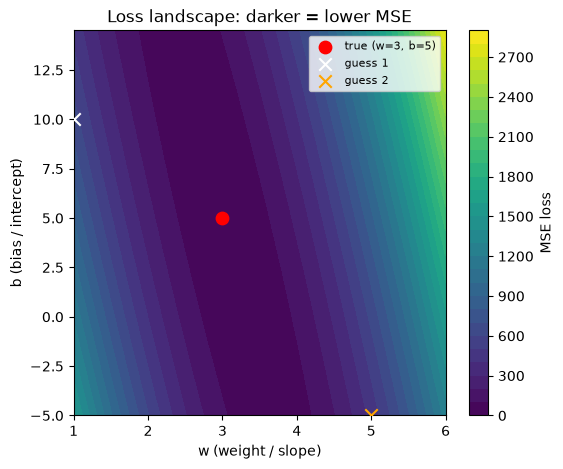

In [5]:
# Sample the loss over a grid of (w, b) values
ws = [i * 0.1 for i in range(10, 61)]   # w from 1.0 to 6.0
bs = [i * 0.5 - 5 for i in range(40)]   # b from -5 to 14.5

Z = [[mse_loss(X, y, w, b) for w in ws] for b in bs]

plt.figure(figsize=(6, 5))
plt.contourf(ws, bs, Z, levels=30, cmap='viridis')
plt.colorbar(label='MSE loss')
plt.scatter([TRUE_W], [TRUE_B], color='red', s=80, zorder=5, label='true (w=3, b=5)')
plt.scatter([w_guess1], [b_guess1], color='white', marker='x', s=80, zorder=5, label='guess 1')
plt.scatter([w_guess2], [b_guess2], color='orange', marker='x', s=80, zorder=5, label='guess 2')
plt.xlabel('w (weight / slope)')
plt.ylabel('b (bias / intercept)')
plt.title('Loss landscape: darker = lower MSE')
plt.legend(fontsize=8)
plt.show()

## Step 4: Gradient Descent

We have a loss that measures badness. We want to minimise it. How?

The naive approach: try every possible `(w, b)` pair and pick the best. Impossible in practice, since the parameter space is infinite.

**Gradient descent** is a much smarter approach. It works like this: stand at a point on the loss surface. Look around you. Walk a small step in the direction that slopes downhill the fastest. Repeat.

### What is a gradient?

The **gradient** is the direction of steepest *ascent*: the direction the loss increases fastest. It's the collection of partial derivatives, one per parameter:

```
gradient = [∂L/∂w,  ∂L/∂b]
```

Each partial derivative answers: "if I increase this one parameter slightly, holding everything else fixed, how much does the loss change?"

- `∂L/∂w > 0` means increasing `w` increases the loss → we should decrease `w`
- `∂L/∂w < 0` means increasing `w` decreases the loss → we should increase `w`

So we step **against** the gradient:

```
w ← w − lr × ∂L/∂w
b ← b − lr × ∂L/∂b
```

The **learning rate** `lr` controls step size. Too large: we overshoot the minimum and bounce around. Too small: we take forever to converge.

### Deriving the gradients for MSE

We need a formula for `∂L/∂w` and `∂L/∂b`. Let's derive them slowly.

**Step 1: one example at a time.** The full MSE sums over every example and divides by `n`. That clutter hides the actual calculus, so start with the loss from a *single* house `(xᵢ, yᵢ)`:

```
Lᵢ = (w*xᵢ + b − yᵢ)²
```

**Step 2: name the inside.** Notice `Lᵢ` is a square wrapped around a simpler expression. Give that inner expression a name. It's just the prediction error:

```
eᵢ = w*xᵢ + b − yᵢ        so that      Lᵢ = eᵢ²
```

We have a function of a function: square, applied to error. That's the signal to use the **chain rule**.

**Step 3: the chain rule.** It says: the derivative of the whole is the derivative of the *outside* times the derivative of the *inside*.

```
∂Lᵢ/∂w = (∂Lᵢ/∂eᵢ) × (∂eᵢ/∂w)
```

Compute each piece separately.

- Outside: `Lᵢ = eᵢ²`, so `∂Lᵢ/∂eᵢ = 2·eᵢ` (the power rule, `d(u²)/du = 2u`).
- Inside: `eᵢ = w*xᵢ + b − yᵢ`. Differentiating with respect to `w`, the terms `b` and `−yᵢ` are constants (they vanish), and `w*xᵢ` leaves `xᵢ`. So `∂eᵢ/∂w = xᵢ`.

Multiply them back together:

```
∂Lᵢ/∂w = 2·eᵢ × xᵢ = 2·(w*xᵢ + b − yᵢ)·xᵢ
```

**Step 4: do the same for `b`.** Only the inside derivative changes. In `eᵢ = w*xᵢ + b − yᵢ`, differentiating with respect to `b` gives `∂eᵢ/∂b = 1` (the `b` term leaves 1; everything else is constant):

```
∂Lᵢ/∂b = 2·eᵢ × 1 = 2·(w*xᵢ + b − yᵢ)
```

**Step 5: put the sum back.** The full loss is the *average* of the per-example losses. A derivative of a sum is the sum of the derivatives, and the `1/n` rides along, so we just average the per-example gradients:

```
∂L/∂w = (2/n) Σ (w*xᵢ + b − yᵢ) · xᵢ
∂L/∂b = (2/n) Σ (w*xᵢ + b − yᵢ)
```

**What these formulas say.** Both gradients are built from the same quantity: the error `(prediction − truth)`, averaged over all examples. For `b`, that's the whole story. It's just the average error. For `w`, each error is scaled by its input `xᵢ` first, so a wrong prediction on a big house pushes `w` harder than the same error on a small one. This "error × input" shape appears in every gradient we compute in later notebooks.

The factor `2/n` only scales the gradient. It changes the step length, not the direction, so it could be folded into the learning rate. We keep it so the code matches the calculus exactly.

### Verifying the gradients numerically

Before trusting our algebra, let's verify. A derivative is a slope, and we can estimate a slope by nudging the input a tiny bit and watching how the loss responds. The **central difference** does this symmetrically: step `h` to each side and measure the rise over the run.

```
∂L/∂w ≈ (L(w + h) − L(w − h)) / (2·h)
```

Stepping both ways beats a one-sided `(L(w + h) − L(w)) / h`: the leading error terms from the two sides cancel, so the estimate is far more accurate for the same `h`. For a small `h`, this should match our analytic formula to several decimal places. If it does, the gradients are correct.

In [6]:
def gradients(X, y, w, b):
    n = len(X)
    dw = (2/n) * sum((predict(xi, w, b) - yi) * xi for xi, yi in zip(X, y))
    db = (2/n) * sum((predict(xi, w, b) - yi) for xi, yi in zip(X, y))
    return dw, db

# Check at a specific point in parameter space
w0, b0 = 1.0, 10.0
dw_analytic, db_analytic = gradients(X, y, w0, b0)

# Numerical check with a central difference: step h to each side, rise over run
h = 1e-5
dw_numerical = (mse_loss(X, y, w0 + h, b0) - mse_loss(X, y, w0 - h, b0)) / (2 * h)
db_numerical = (mse_loss(X, y, w0, b0 + h) - mse_loss(X, y, w0, b0 - h)) / (2 * h)

print(f'∂L/∂w  analytic: {dw_analytic:.6f}  |  numerical: {dw_numerical:.6f}')
print(f'∂L/∂b  analytic: {db_analytic:.6f}  |  numerical: {db_numerical:.6f}')

ok = abs(dw_analytic - dw_numerical) < 1e-4 and abs(db_analytic - db_numerical) < 1e-4
print('Match!' if ok else 'MISMATCH: check the algebra')

∂L/∂w  analytic: -738.198525  |  numerical: -738.198525
∂L/∂b  analytic: -43.930222  |  numerical: -43.930222
Match!


## Step 5: The Training Loop

Every ML model in this series is trained by the same four steps, repeated:

1. **Predict**: run the inputs through the model with its current parameters to get predictions.
2. **Score**: compute the loss, a single number measuring how wrong the predictions are.
3. **Assign blame**: compute the gradient. For each parameter, how much does the loss change if I nudge it?
4. **Nudge**: update each parameter a small step against its gradient.

This is it. Everything else in deep learning (attention, embeddings, transformers) lives inside step 1. Steps 2 to 4 are structurally identical across every model.

Let's train linear regression and watch the parameters converge. One thing to expect before running it: the best fit for a *noisy sample* is not exactly the generating values `w=3, b=5`. The noise pulls the optimum a little away from them. So the right benchmark for gradient descent is the closed-form least-squares solution for this particular dataset, which we compute at the end of the cell as a sanity check.

Final:  w = 3.070  b = 4.074
Final loss: 15.52
Closed-form optimum: w = 3.068  b = 4.104  (generating values: w=3.0, b=5.0)


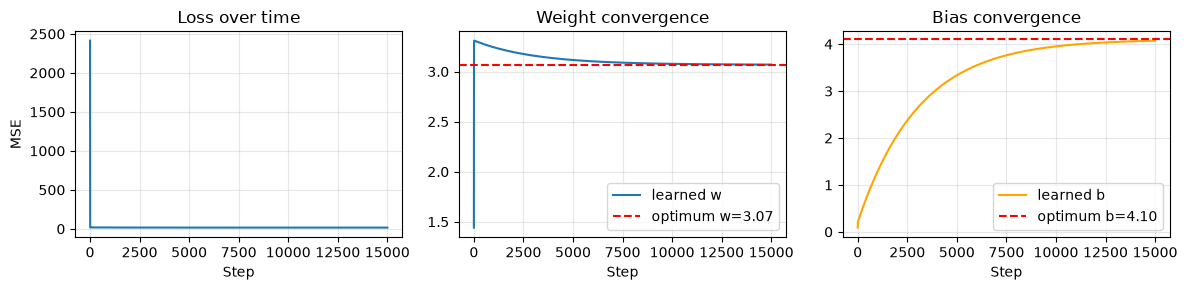

In [7]:
# Initialise parameters at a bad guess
w = 0.0
b = 0.0
lr = 0.001

history = []  # (step, loss, w, b)

for step in range(15000):
    # 1. Predict
    preds = [predict(xi, w, b) for xi in X]

    # 2. Score
    loss = sum((pi - yi) ** 2 for pi, yi in zip(preds, y)) / len(y)

    # 3. Assign blame (gradient)
    dw, db = gradients(X, y, w, b)

    # 4. Nudge: step against the gradient
    w = w - lr * dw
    b = b - lr * db

    history.append((step, loss, w, b))

steps_, losses_, ws_, bs_ = zip(*history)

print(f'Final:  w = {w:.3f}  b = {b:.3f}')
print(f'Final loss: {losses_[-1]:.2f}')

# Sanity check: compare against the closed-form least-squares solution.
# For a straight line this can be solved exactly; gradient descent should land there.
mean_x = sum(X) / len(X)
mean_y = sum(y) / len(y)
w_best = sum((xi - mean_x) * (yi - mean_y) for xi, yi in zip(X, y)) / sum((xi - mean_x) ** 2 for xi in X)
b_best = mean_y - w_best * mean_x
print(f'Closed-form optimum: w = {w_best:.3f}  b = {b_best:.3f}  (generating values: w={TRUE_W}, b={TRUE_B})')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(steps_, losses_)
axes[0].set_title('Loss over time'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE')
axes[0].grid(alpha=0.3)

axes[1].plot(steps_, ws_, label='learned w')
axes[1].axhline(w_best, color='r', linestyle='--', label=f'optimum w={w_best:.2f}')
axes[1].set_title('Weight convergence'); axes[1].set_xlabel('Step'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(steps_, bs_, label='learned b', color='orange')
axes[2].axhline(b_best, color='r', linestyle='--', label=f'optimum b={b_best:.2f}')
axes[2].set_title('Bias convergence'); axes[2].set_xlabel('Step'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

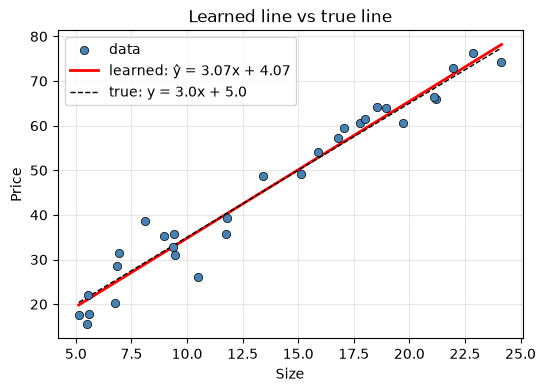

In [8]:
# Plot the learned line against the data
x_line = [min(X), max(X)]

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='steelblue', edgecolors='k', linewidth=0.5, zorder=3, label='data')
plt.plot(x_line, [predict(xi, w, b) for xi in x_line], 'r-', linewidth=2, label=f'learned: ŷ = {w:.2f}x + {b:.2f}')
plt.plot(x_line, [TRUE_W * xi + TRUE_B for xi in x_line], 'k--', linewidth=1, label=f'true: y = {TRUE_W}x + {TRUE_B}')
plt.xlabel('Size'); plt.ylabel('Price')
plt.title('Learned line vs true line')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Step 6: Generalization and the Train/Val Split

The model learned a good line. But we evaluated it on the same data it trained on. Is that a fair test?

No. The model had access to every example during training. A sufficiently powerful model can *memorise* every training point without learning anything about the underlying pattern. It would score a loss of zero on training data while being useless on any new data.

This is called **overfitting**: the model fits the training data too closely, capturing its noise instead of its signal.

**Underfitting** is the opposite problem: the model is too simple to capture the true pattern even on training data.

What we actually care about is **generalisation**: how well the model performs on examples it has never seen. The standard technique to measure this is the **train/validation split**:

1. Split your data into two disjoint sets: **training** (typically 80%) and **validation** (typically 20%).
2. Train the model using only the training set.
3. Evaluate on the validation set. The model has never seen these examples.

If training loss is much lower than validation loss, the model is overfitting. If both are high, it's underfitting.

### Demonstrating overfitting

To see all three regimes, we need data with a gentle curve. A straight line is too simple to follow it (**underfitting**), while a high-capacity **polynomial** has enough parameters to twist through every training point, noise and all (**overfitting**). Somewhere in between sits a model that captures the real shape and generalises.

A polynomial feeds powers of the input into the same linear machinery:

```
ŷ = w₁·x + w₂·x² + w₃·x³ + ... + w_d·x^d + b
```

The degree `d` controls **capacity**: how much the curve is allowed to bend. We'll build a curved dataset, split it 80/20, and fit degree 1, 3, and 10 to it.

In [9]:
# A curve to fit: a straight line can't overfit our linear house data, and it
# can't underfit it either. So we build a small dataset with a gentle upward
# curve, then split it 80/20 to measure generalisation.
random.seed(0)

n_poly = 24
X_poly = [random.uniform(5, 25) for _ in range(n_poly)]
# True pattern: a gentle parabola + noise
y_poly = [0.08 * (xi - 15) ** 2 + 0.4 * xi + 12 + random.gauss(0, 1.5) for xi in X_poly]

data = list(zip(X_poly, y_poly))
random.shuffle(data)
split = int(0.8 * len(data))
X_tr, y_tr = [d[0] for d in data[:split]], [d[1] for d in data[:split]]
X_va, y_va = [d[0] for d in data[split:]], [d[1] for d in data[split:]]
print(f'Train: {len(X_tr)} examples  |  Val: {len(X_va)} examples')

Train: 19 examples  |  Val: 5 examples


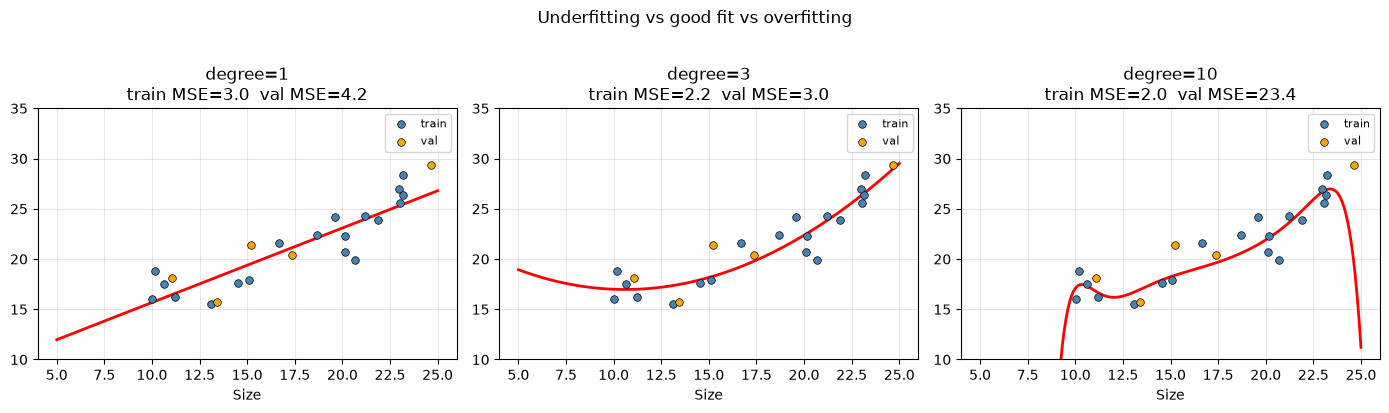

In [10]:
# Polynomial features: expand x -> [x, x², x³, ..., x^degree]
# This lets a linear model learn curves: more features = more flexibility.
#
# One catch: raw powers of x explode. With x up to 25, the degree-10 feature x¹⁰
# is about 10¹³, dwarfing x¹. That wrecks gradient descent: the tiny learning
# rate the huge features demand leaves the small ones barely trained, and the huge
# ones overflow to NaN. The fix is to standardise x first, using the training set's
# mean and std, so every power sits on a comparable scale.
mean = sum(X_tr) / len(X_tr)
std = (sum((xi - mean) ** 2 for xi in X_tr) / len(X_tr)) ** 0.5

def z(x):
    return (x - mean) / std

def poly_features(x, degree):
    return [z(x) ** d for d in range(1, degree + 1)]

def poly_predict(x, weights, bias, degree):
    feats = poly_features(x, degree)
    return sum(w * f for w, f in zip(weights, feats)) + bias

def poly_loss(X, y, weights, bias, degree):
    n = len(X)
    return sum((poly_predict(xi, weights, bias, degree) - yi) ** 2 for xi, yi in zip(X, y)) / n

def train_poly(X, y, degree, lr, steps):
    weights = [0.0] * degree
    bias = 0.0
    n = len(X)
    for _ in range(steps):
        errors = [poly_predict(xi, weights, bias, degree) - yi for xi, yi in zip(X, y)]
        dweights = [(2/n) * sum(e * (z(xi) ** d) for e, xi in zip(errors, X))
                    for d in range(1, degree + 1)]
        dbias = (2/n) * sum(errors)
        weights = [w - lr * dw for w, dw in zip(weights, dweights)]
        bias = bias - lr * dbias
    return weights, bias

# Even after standardising, the high-degree loss surface is steeper and more
# ill-conditioned, so degree 10 needs a smaller learning rate and more steps.
settings = {1: (0.02, 30000), 3: (0.02, 30000), 10: (2e-4, 60000)}

# Train models of increasing complexity
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x_plot = [5 + i * 0.1 for i in range(201)]

for ax, degree in zip(axes, [1, 3, 10]):
    lr, steps = settings[degree]
    w_poly, b_poly = train_poly(X_tr, y_tr, degree, lr, steps)
    tr_loss = poly_loss(X_tr, y_tr, w_poly, b_poly, degree)
    va_loss = poly_loss(X_va, y_va, w_poly, b_poly, degree)

    ax.scatter(X_tr, y_tr, color='steelblue', edgecolors='k', linewidth=0.5, s=30, label='train', zorder=3)
    ax.scatter(X_va, y_va, color='orange',    edgecolors='k', linewidth=0.5, s=30, label='val',   zorder=3)
    ax.plot(x_plot, [poly_predict(xi, w_poly, b_poly, degree) for xi in x_plot], 'r-', linewidth=2)
    ax.set_title(f'degree={degree}\ntrain MSE={tr_loss:.1f}  val MSE={va_loss:.1f}')
    ax.set_ylim(10, 35); ax.set_xlabel('Size'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Underfitting vs good fit vs overfitting', y=1.02)
plt.tight_layout()
plt.show()

The pattern: as degree increases, **training loss keeps falling** (3.0 → 2.2 → 2.0), because a more flexible curve fits the training points ever more closely. But **validation loss is U-shaped** (4.2 → 3.0 → 23.4): it drops from degree 1 to 3, then jumps at degree 10.

Each panel shows why. The degree-1 line is too stiff to follow the curve, so it has high error on both sets (**underfitting**). The degree-10 curve wiggles through the training points, memorising noise, and swings wildly between them: low training error, terrible validation error (**overfitting**). Degree 3 has just enough flexibility to capture the shape without chasing noise, so it generalises best.

This is the central challenge of ML: **models should generalise, not memorise.** Training loss alone can't see the difference, since it only ever goes down as capacity grows. The validation set is the only honest measure. From here on, every notebook in this series uses a train/val split and tracks both losses.

## Step 7: Classification

Regression predicts a continuous number (price, temperature). **Classification** predicts a category (spam or not spam, cat or dog).

The simplest classifier is **logistic regression**. Despite the name, it's a classifier. It applies a sigmoid function to the output of a linear model:

```
z = w * x + b          (linear score, any real number)
ŷ = σ(z) = 1 / (1 + e^(-z))  (squash to (0, 1) = probability)
```

The **sigmoid** `σ` maps any score to the range `(0, 1)`. We interpret `ŷ` as the probability of the positive class:
- `ŷ` close to 1 → model is confident it's class 1
- `ŷ` close to 0 → model is confident it's class 0
- `ŷ` ≈ 0.5 → the model is uncertain

### Why not just use MSE for classification?

You could. But it has two problems.

First, MSE doesn't penalise wrong, confident predictions strongly enough. If the model says `ŷ = 0.99` for a label of `0`, the MSE error is `(0.99 - 0)² = 0.98`. If it says `ŷ = 0.999`, the error is `0.998`: barely worse despite being more confidently wrong.

Second, and sneakier: the *gradient* of MSE through a sigmoid carries a factor of `σ'(z)` (the sigmoid's slope), and that slope is nearly zero exactly where the sigmoid is saturated, i.e. where the model is confident. A confidently *wrong* model therefore receives almost no gradient signal, and learning stalls right where the biggest correction is needed.

**Binary cross-entropy** fixes both:

```
L = −(y * log(ŷ) + (1 − y) * log(1 − ŷ))
```

When `y = 1` (true class is 1), only the first term survives: `−log(ŷ)`. This is 0 when `ŷ = 1` (correct, confident), and grows without bound as `ŷ → 0` (wrong, confident). And when you push its gradient through the sigmoid, the algebra cancels the `σ'(z)` factor, leaving plain `(ŷ − y)` per example: the more wrong the model, the stronger the push. That is the "error × input" shape from Step 4 again, and it's why the gradient code below looks so familiar.

### A 1D classification task

We'll classify by house size: small houses (below 15) are class 0, large houses are class 1, with a little noise near the boundary as in real data. One weight `w`, one bias `b`: the simplest possible classifier.

A sanity check to carry into training: at `w = 0, b = 0` the model outputs `ŷ = 0.5` for every input, so the untrained loss should be `−log(0.5) = log 2 ≈ 0.693`. Training should start there and go down.

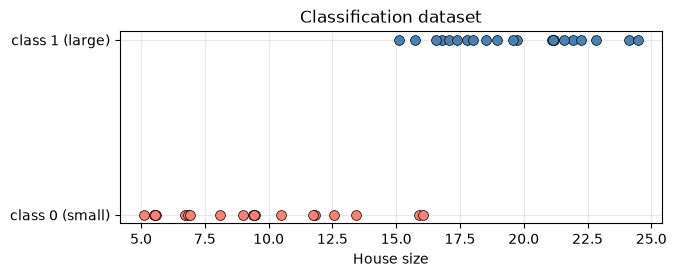

In [11]:
random.seed(42)

def sigmoid(z):
    return 1.0 / (1.0 + math.exp(-z))

def logistic_predict(x, w, b):
    return sigmoid(w * x + b)

# Generate classification data: 1 feature (size), binary label
n_cls = 40
X_cls = [random.uniform(5, 25) for _ in range(n_cls)]
# Label: 1 if large (> 15 + noise), 0 if small
y_cls = [1 if xi + random.gauss(0, 2) > 15 else 0 for xi in X_cls]

plt.figure(figsize=(7, 2.5))
for xi, yi in zip(X_cls, y_cls):
    plt.scatter(xi, yi, color='steelblue' if yi == 1 else 'salmon', edgecolors='k', linewidth=0.5, s=50, zorder=3)
plt.yticks([0, 1], ['class 0 (small)', 'class 1 (large)'])
plt.xlabel('House size'); plt.title('Classification dataset')
plt.grid(alpha=0.3)
plt.show()

In [12]:
def bce_loss(X, y, w, b):
    n = len(X)
    eps = 1e-15  # avoid log(0)
    total = 0.0
    for xi, yi in zip(X, y):
        p = logistic_predict(xi, w, b)
        p = max(eps, min(1 - eps, p))
        total += -(yi * math.log(p) + (1 - yi) * math.log(1 - p))
    return total / n

# Gradients for binary cross-entropy (the sigmoid's slope cancels, see above):
# ∂L/∂w = (1/n) Σ (ŷᵢ − yᵢ) * xᵢ
# ∂L/∂b = (1/n) Σ (ŷᵢ − yᵢ)
def logistic_gradients(X, y, w, b):
    n = len(X)
    errors = [logistic_predict(xi, w, b) - yi for xi, yi in zip(X, y)]
    dw = sum(e * xi for e, xi in zip(errors, X)) / n
    db = sum(errors) / n
    return dw, db

# Train. Note the learning rate: x runs from 5 to 25 and is not standardised,
# so a large lr (say 0.1) makes the updates overshoot and the loss oscillate.
# lr=0.02 descends smoothly; it just needs a few thousand steps.
w_cls = 0.0
b_cls = 0.0
lr_cls = 0.02

# Sanity check: an untrained model predicts 0.5 everywhere -> loss = log 2
print(f'Untrained loss: {bce_loss(X_cls, y_cls, w_cls, b_cls):.4f}  (log 2 = {math.log(2):.4f})')

cls_history = []
for step in range(5000):
    loss_cls = bce_loss(X_cls, y_cls, w_cls, b_cls)
    dw, db = logistic_gradients(X_cls, y_cls, w_cls, b_cls)
    w_cls -= lr_cls * dw
    b_cls -= lr_cls * db
    cls_history.append(loss_cls)

print(f'Final: w={w_cls:.3f}, b={b_cls:.3f}')
print(f'Final loss: {cls_history[-1]:.4f}')

# Accuracy
acc = sum((logistic_predict(xi, w_cls, b_cls) > 0.5) == bool(yi) for xi, yi in zip(X_cls, y_cls)) / len(X_cls)
print(f'Training accuracy: {acc*100:.0f}%')

Untrained loss: 0.6931  (log 2 = 0.6931)
Final: w=0.406, b=-5.688
Final loss: 0.2081
Training accuracy: 95%


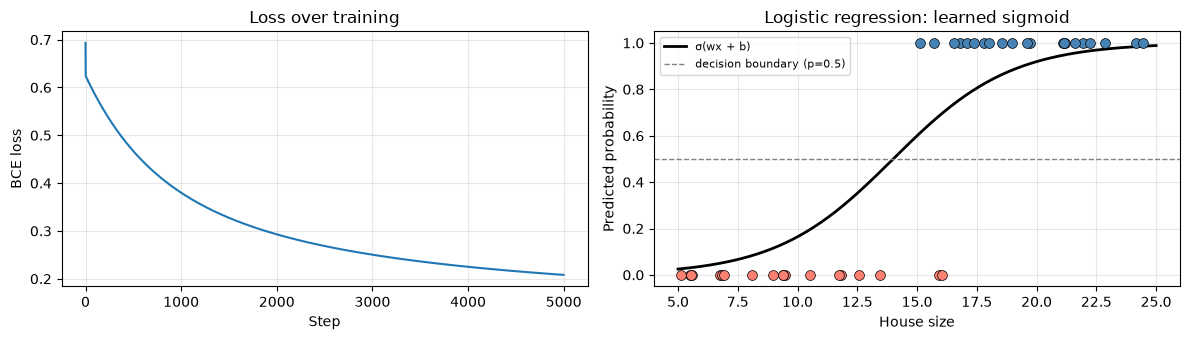

Decision boundary at x = 14.00  (houses larger than this are predicted class 1)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Loss curve
axes[0].plot(cls_history)
axes[0].set_title('Loss over training'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('BCE loss')
axes[0].grid(alpha=0.3)

# Sigmoid curve + data
x_plot = [5 + i * 0.1 for i in range(201)]
sigmoid_vals = [logistic_predict(xi, w_cls, b_cls) for xi in x_plot]

for xi, yi in zip(X_cls, y_cls):
    axes[1].scatter(xi, yi, color='steelblue' if yi == 1 else 'salmon',
                    edgecolors='k', linewidth=0.5, s=50, zorder=3)
axes[1].plot(x_plot, sigmoid_vals, 'k-', linewidth=2, label='σ(wx + b)')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='decision boundary (p=0.5)')
axes[1].set_xlabel('House size'); axes[1].set_ylabel('Predicted probability')
axes[1].set_title('Logistic regression: learned sigmoid')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Decision boundary: where sigmoid = 0.5, i.e., w*x + b = 0, i.e., x = -b/w
decision_boundary = -b_cls / w_cls
print(f'Decision boundary at x = {decision_boundary:.2f}  (houses larger than this are predicted class 1)')

## Summary

Everything in this notebook:

| Concept | What it is | Where it shows up next |
|---------|-----------|----------------------|
| Features, targets, parameters | The vocabulary of supervised learning | Every notebook |
| Linear model | `ŷ = w*x + b`, the simplest function | Neurons, attention, everything |
| MSE loss | Average squared error: how wrong we are | Regression tasks |
| Gradient | Direction of steepest ascent: step the other way | `loss.backward()` in PyTorch |
| Gradient descent | Repeat: predict → score → gradient → nudge | Every training loop |
| Train/val split | Train on one set, evaluate on another | All subsequent notebooks |
| Overfitting | Memorising training noise, failing on new data | Why regularisation exists |
| Sigmoid | Squash any score to `(0, 1)` = probability | Classification heads |
| Binary cross-entropy | Loss for binary classification | Language modelling (multi-class version) |

### What we learned

- **ML is learning from examples, not writing rules.** The rules are encoded in numbers (parameters) that adjust themselves.
- **The four-step training loop is universal.** Predict. Score. Assign blame. Nudge. Everything else is what you put in step 1.
- **The gradient is the nudge signal.** Its sign says which way to adjust; its magnitude says how much that parameter matters right now.
- **Validation loss is the only honest measure.** Training loss tells you how well the model memorised the training set; validation loss tells you whether it learned something real.
- **Classification changes the output and the loss, not the loop.** A sigmoid turns the linear score into a probability, cross-entropy replaces MSE, and the four training steps stay exactly the same.
- **Learning rate and feature scale interact.** The same lr that trains one model smoothly makes another oscillate or diverge; unscaled inputs are usually the culprit. We hit this twice: polynomial features and the logistic classifier.

### What's next

A linear model can only draw straight lines. Real tasks, like predicting the next character of Shakespeare or classifying a photo, need curved, complex decision boundaries. The next notebook replaces the linear model with a **neural network**: neurons arranged in layers, trained by the same four-step loop, but capable of learning any function given enough parameters.

> ➡ **Next in the series:** [Building a Neural Network from Scratch](2_neural_net.ipynb)

## Your turn: make it stick

### 1. Summarise from memory

Close the notebook and answer these without peeking:

- What are the four steps of the training loop? What does each one produce?
- Why do we square the errors in MSE? What would happen if we just averaged raw errors?
- Why can't we evaluate a model on its training data and call that its performance?
- What does the sigmoid do and why do we need it for classification?
- What is the gradient? What does its sign tell you? What does its magnitude tell you?

Then check your answers with an LLM and ask it to quiz you on any gaps.

### 2. Experiment with the training loop

In the linear regression training cell, try:

1. Set `lr = 0.1` (100× larger). What happens to training? Why?
2. Set `lr = 0.000001` (100× smaller). How many steps does it take to converge?
3. Start from `w = 10.0, b = -20.0`. Does the training loop still converge to the same optimum?
4. Look at the middle and right convergence plots. `w` snaps into place within a few hundred steps, but `b` crawls for thousands. Why? (Hint: compare the size of `∂L/∂w` and `∂L/∂b` in the gradient formulas when `x` averages around 15.)

For (1): if training explodes, look at the gradient formula and think about what a large `lr` does to the update step.

### 3. Rebuild the loop from scratch

In a blank file, with no copying, implement:

1. `predict(x, w, b)` and `mse_loss(X, y, w, b)`
2. `gradients(X, y, w, b)`: work out the derivatives by hand first, then verify against the numerical approximation
3. The training loop: 15,000 steps at `lr = 0.001`, starting from `w=0, b=0`

**Done when**: the learned `w` is within 0.1 of the closed-form optimum and `b` is within 0.5 of it. (Don't expect to land exactly on the generating values `w=3, b=5`; as we saw in Step 5, noise moves the optimum.)

> ➡ **Next in the series:** [Building a Neural Network from Scratch](2_neural_net.ipynb)